In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

filename = 'side_output.csv'
df = pd.read_csv(filename, header=None,index_col=0).T

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

65544
夹零比例
56.387%


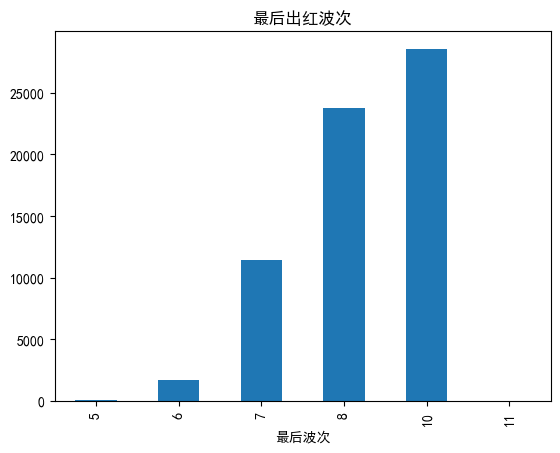

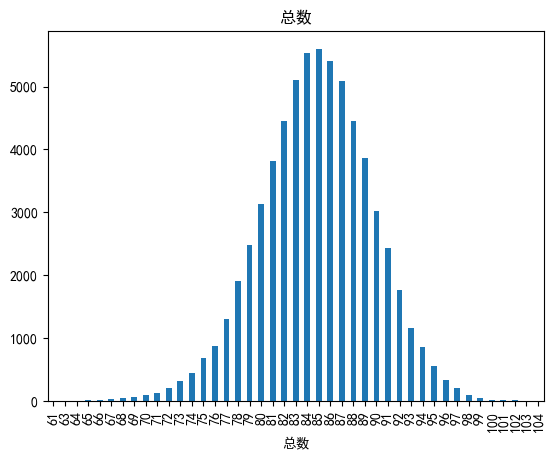

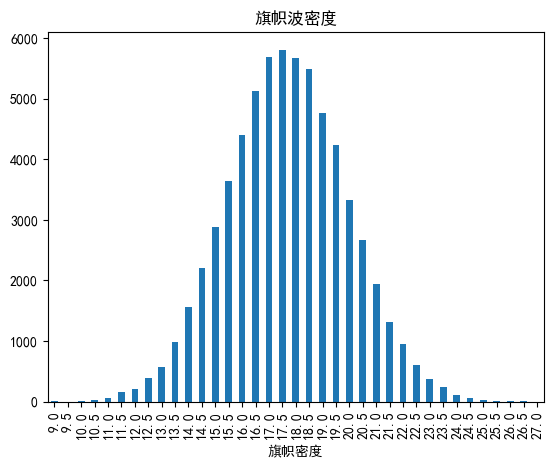

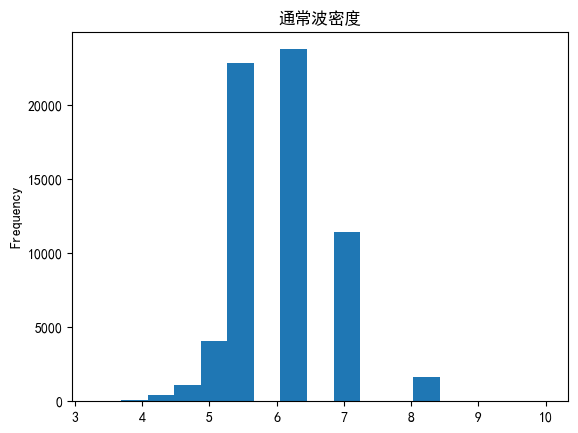

In [3]:
# 红眼
# # print(df)
df['普通总数']=df['总数']-df['旗帜总数']
df['旗帜密度']=1.0*df['旗帜总数']/2
df['普通波次']=df['最后波次']-1
for index, row in df.iterrows():
    if row['最后波次'] <= 9:
        df.at[index, '普通波次'] = row['普通波次'] + 1
df['普通密度']=1.0*(df['总数']-df['旗帜总数'])/df['普通波次']

# print(df)
print(len(df))

value_counts = df['不夹零'].value_counts()
print(f'夹零比例\n{100.0*value_counts[0]/(value_counts[0]+value_counts[1]):.3f}%')

value_counts = df['最后波次'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('最后出红波次')
plt.show()

value_counts = df['总数'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('总数')
plt.show()

value_counts = df['旗帜密度'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('旗帜波密度')
plt.show()

df['普通密度'].plot(kind='hist', bins=int(math.log(len(df),2)+1))  
plt.title('通常波密度')
plt.show()

65544
0     10.637846
1     10.632506
2     10.599414
3     10.626953
4     10.657116
5     10.613069
6     10.617768
7     10.661647
8     10.636199
9      7.866044
10    10.631820
11    10.634368
12    10.613527
13    10.626968
14    10.648419
15    10.619538
16    10.614274
17    10.636900
18    10.641706
19     7.867478
dtype: float64


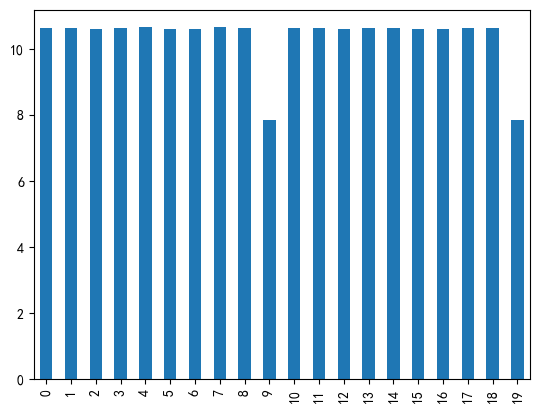

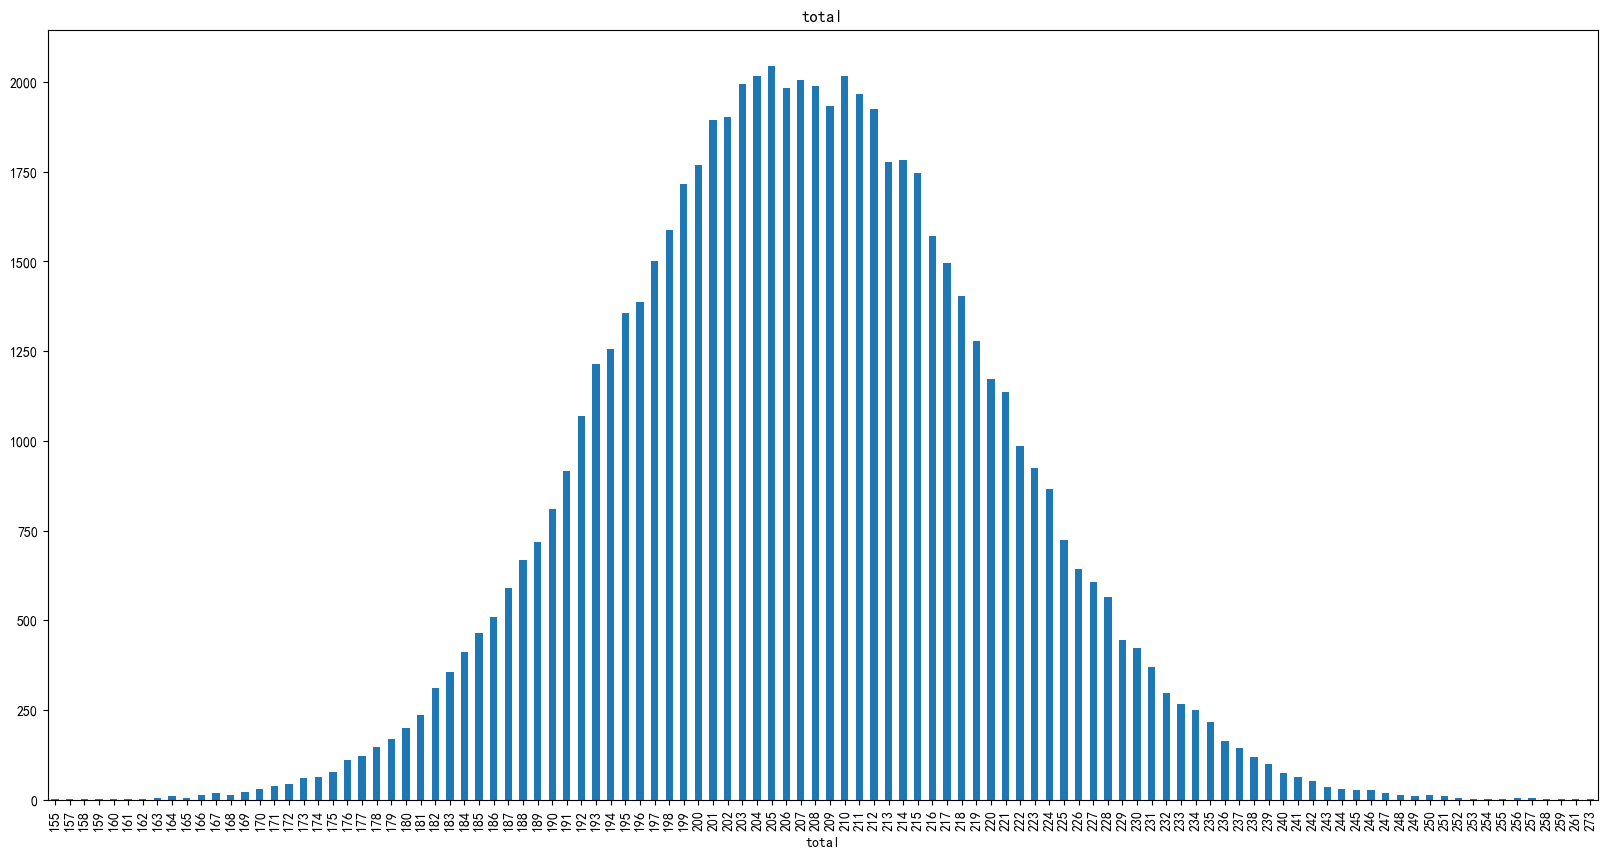

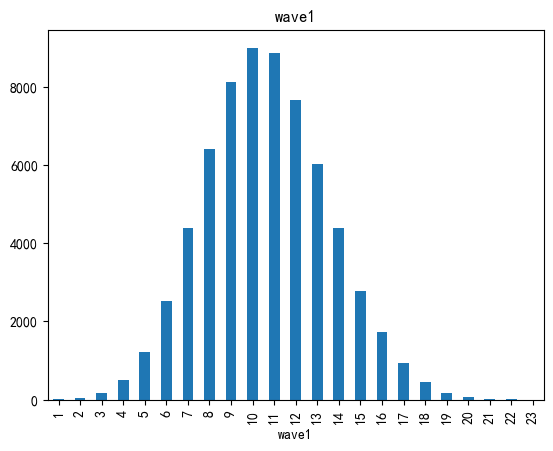

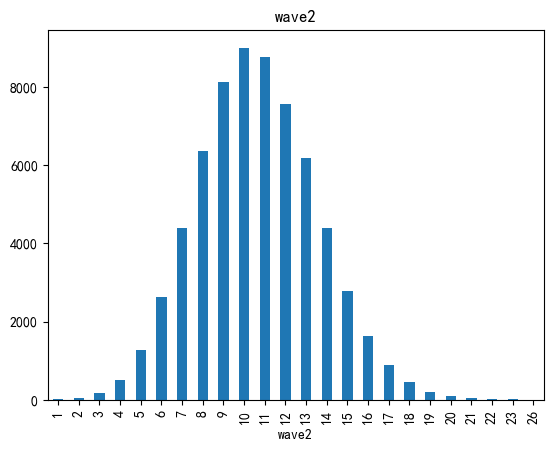

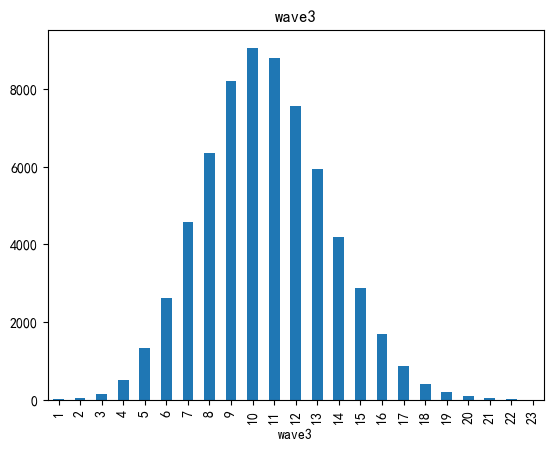

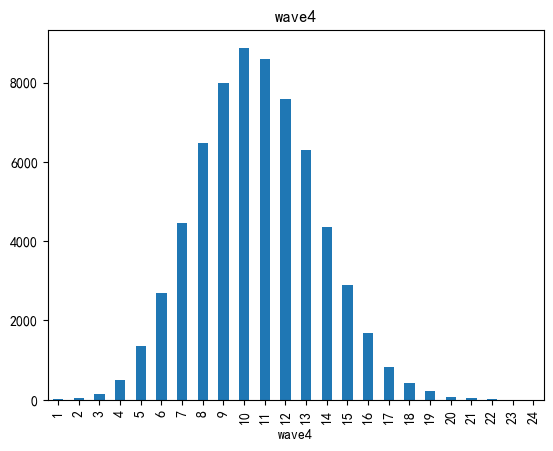

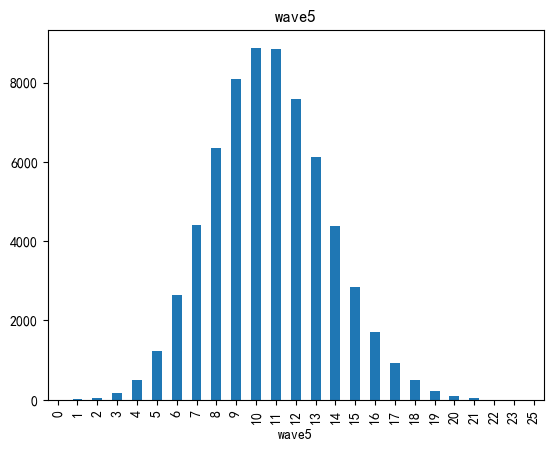

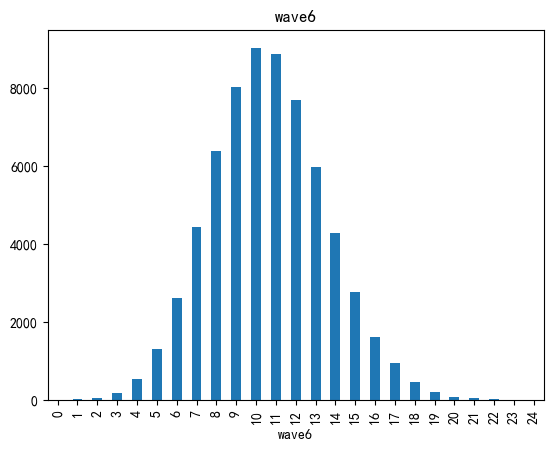

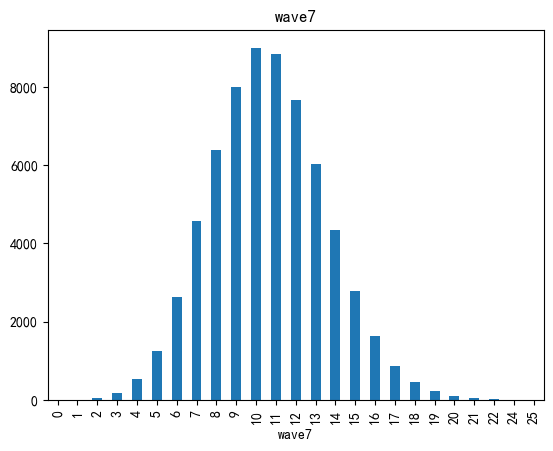

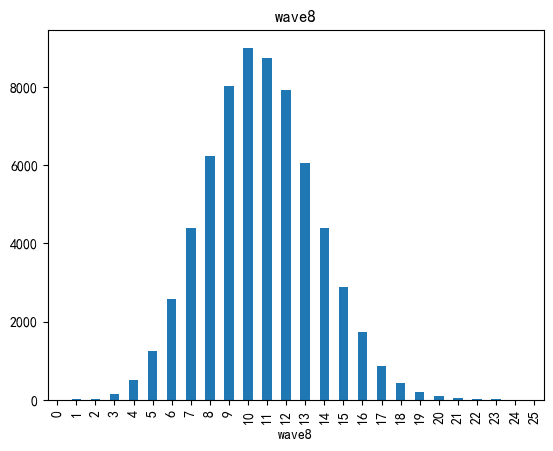

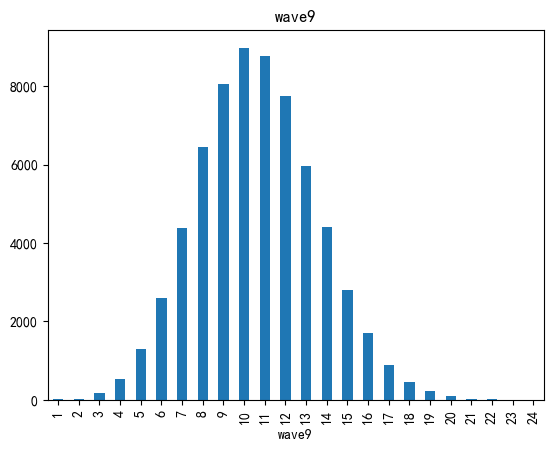

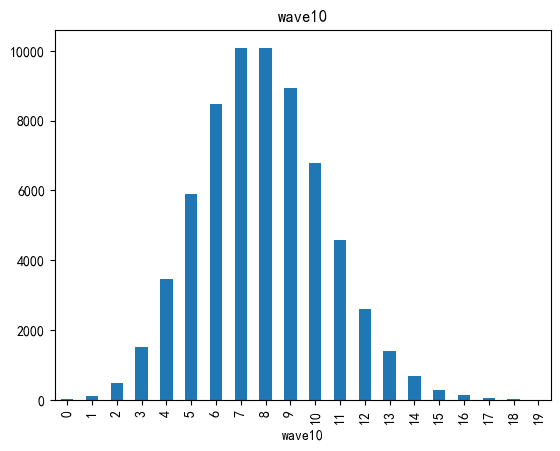

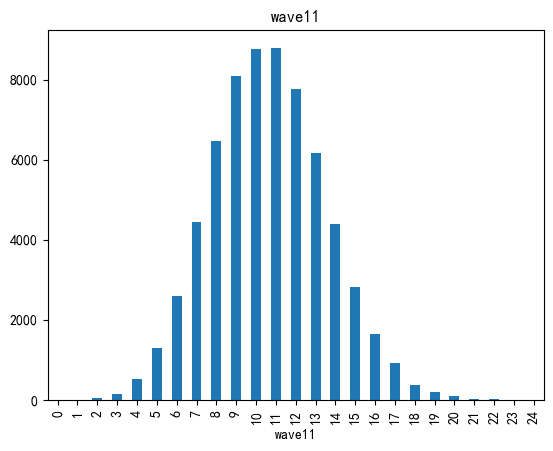

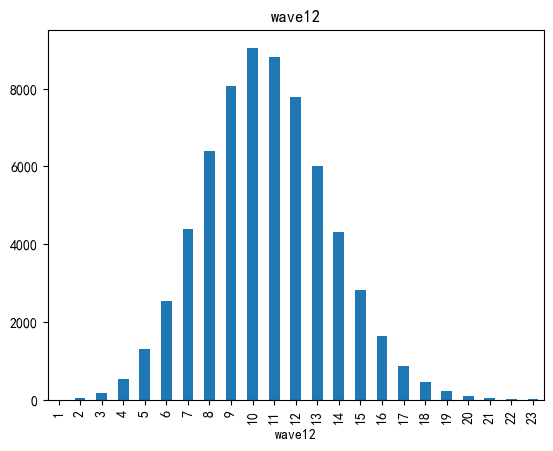

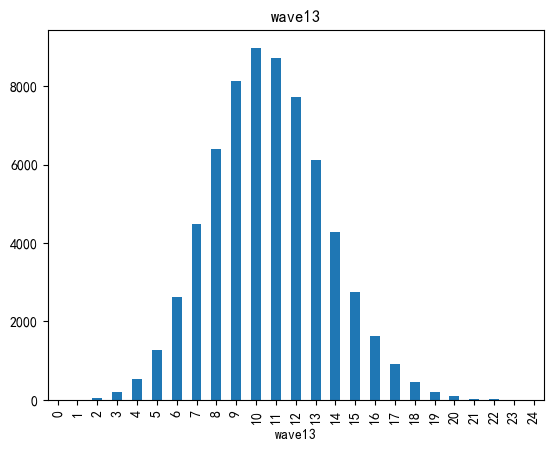

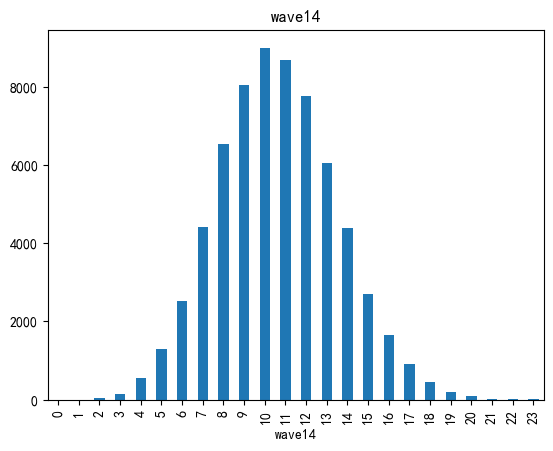

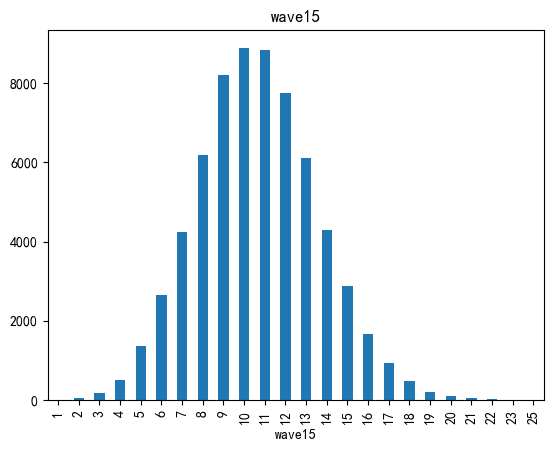

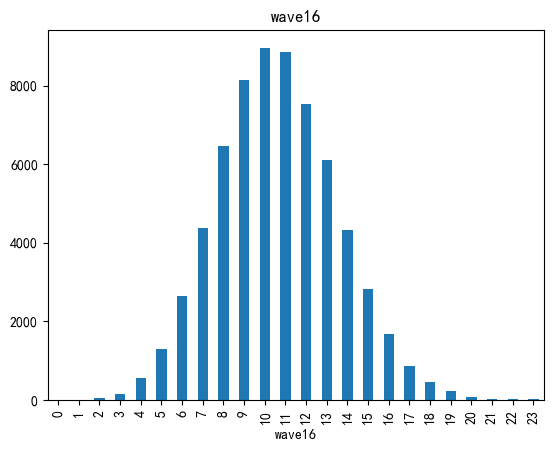

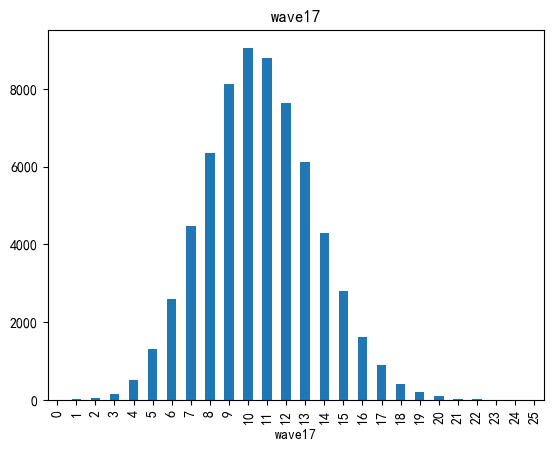

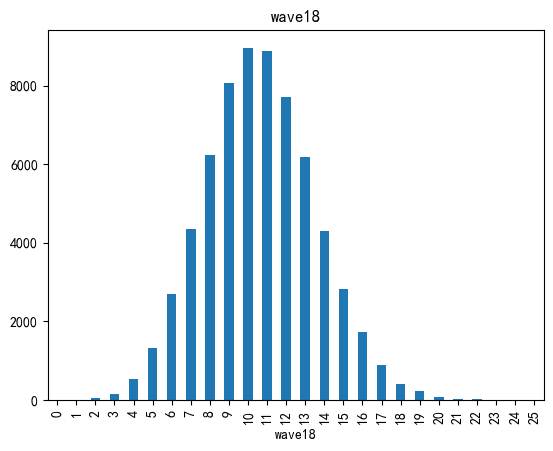

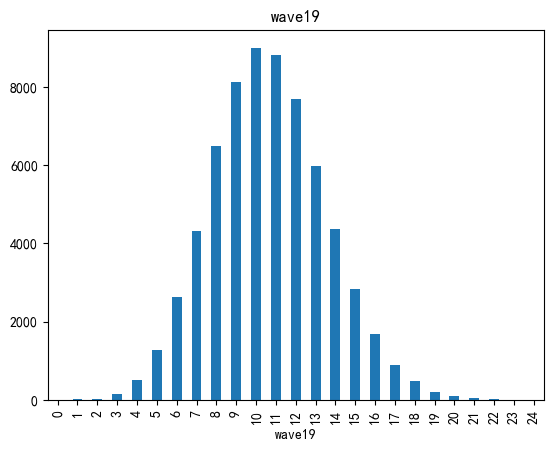

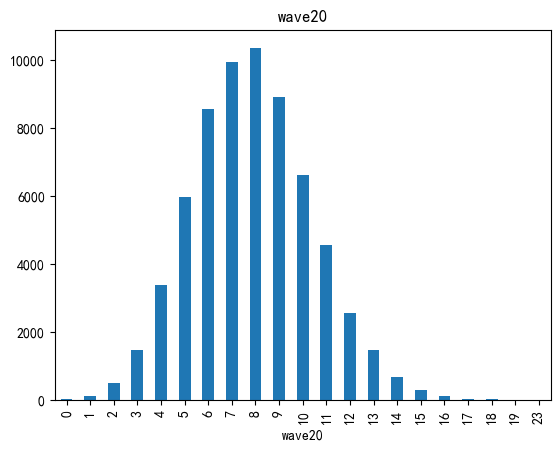

In [6]:
# 冰车
print(len(df))

num_list = pd.Series([df[f'wave{i}'].mean() for i in range(1,21)])
print(num_list)
num_list.plot(kind='bar')
plt.show()


plt.figure(figsize=(20,10))
value_counts = df['total'].value_counts().sort_index()  
value_counts.plot(kind='bar')
plt.title('total')
plt.show()

for i in range(1,21):
    value_counts = df[f'wave{i}'].value_counts().sort_index()  
    value_counts.plot(kind='bar')
    plt.title(f'wave{i}')
    plt.show()



37.12%


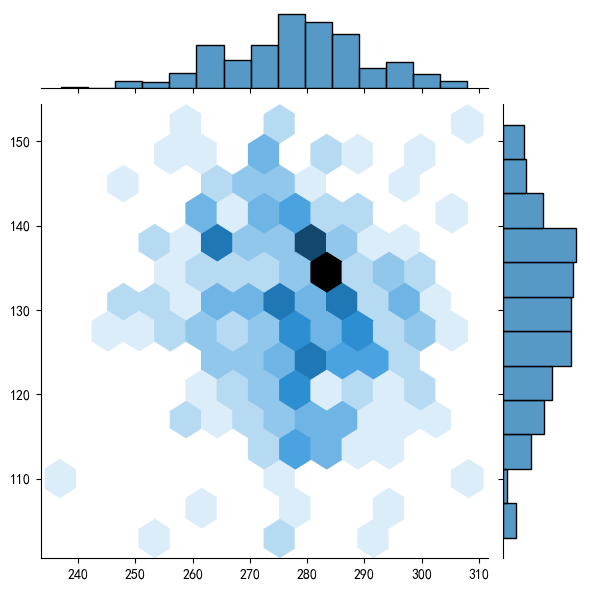

In [2]:
# 南瓜压力分析
df['XG']=df['BY']+df['HY']
N = len(df)

cnt = 0
for i in range(N):
    if df.iloc[i]['XG']>=280-10 and df.iloc[i]['KG']>=140-10:
        cnt = cnt+1
print(f'{100.0*cnt/N:.2f}%')

# 使用seaborn的联合分布图来可视化二维随机变量Z的经验分布
X = df['XG'].to_numpy()
Y = df['KG'].to_numpy()

Z = np.column_stack((X, Y))  # 将X和Y组合成一个二维数组

def empirical_distribution_function(data):
    data_sorted = np.sort(data, axis=0)
    edf = np.arange(1, N+1) / N
    return data_sorted, edf
X_sorted, X_edf = empirical_distribution_function(X)
Y_sorted, Y_edf = empirical_distribution_function(Y)

sns.jointplot(x=X, y=Y, kind='hex')
plt.show()